<a href="https://colab.research.google.com/github/Himanshu-Raghav1/Fix_My_City/blob/main/AQI_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importing all the modules needed
print("Importing all the modules needed\n")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importing all the modules needed



In [3]:
#Uploading the data and printing the first 5 rows of it
print("Uploading the data and printing the first 5 rows of it\n")
df=pd.read_csv("MAHARASHTRA.csv")
df.drop('Station',axis=1,inplace=True)
print(len(df))
df.head()

Uploading the data and printing the first 5 rows of it

40112


,From Date,To Date,Ozone,CO,SO2,NO2,PM10,PM2.5,State,City
0,01-08-2021 00:00,02-08-2021 00:00,NaN,NaN,NaN,6.31,NaN,14.08,Maharashtra,Mumbai
1,02-08-2021 00:00,03-08-2021 00:00,20.13,0.64,2.18,8.92,46.17,14.33,Maharashtra,Mumbai
2,03-08-2021 00:00,04-08-2021 00:00,16.45,0.62,2.35,7.26,34.67,11.63,Maharashtra,Mumbai
3,04-08-2021 00:00,05-08-2021 00:00,15.61,0.61,2.31,6.92,47.70,15.29,Maharashtra,Mumbai
4,05-08-2021 00:00,06-08-2021 00:00,21.13,0.66,2.48,6.78,60.44,17.58,Maharashtra,Mumbai


In [4]:
#Columns that do not have values of any of the pollutant
missing=df[['Ozone','CO','SO2','NO2','PM10','PM2.5']].isnull().any(axis=1).sum()
print("Total of",missing,"values are not available")

Total of 26444 values are not available


In [5]:
#Information of each column present in the data
print("Information of each column present in the data\n")
df.info()

Information of each column present in the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40112 entries, 0 to 40111
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   From Date  40111 non-null  object 
 1   To Date    40111 non-null  object 
 2   Ozone      16527 non-null  float64
 3   CO         17568 non-null  float64
 4   SO2        17732 non-null  float64
 5   NO2        17887 non-null  float64
 6   PM10       17610 non-null  float64
 7   PM2.5      17075 non-null  float64
 8   State      40111 non-null  object 
 9   City       40111 non-null  object 
dtypes: float64(6), object(4)
memory usage: 3.1+ MB


In [6]:
#Statistics of the dataset
print("Statistics of the dataset\n")
df.describe()

Statistics of the dataset



,Ozone,CO,SO2,NO2,PM10,PM2.5
count,16527.000000,17568.000000,17732.000000,17887.000000,17610.000000,17075.000000
mean,28.532810,0.994608,17.747689,28.449592,108.668156,45.979591
std,22.856938,0.718609,22.972469,40.295161,79.165715,40.888066
min,0.010000,0.000000,0.010000,0.010000,0.170000,0.050000
25%,11.505000,0.470000,5.217500,9.440000,51.062500,18.570000
50%,23.570000,0.850000,11.280000,18.490000,88.610000,34.940000
75%,40.460000,1.310000,21.822500,34.470000,149.887500,63.120000
max,187.170000,9.230000,197.780000,500.000000,1000.000000,833.800000


In [7]:
#The cities present in the dataset
print("The cities present in the dataset\n")
cities=df["City"].unique()
for i in cities:
  print(i)


The cities present in the dataset

Mumbai
Chandrapur
Pune
Solapur
Nagpur
Nashik
Thane
Navi Mumbai
Kalyan
Pimpri-Chinchwad
Kolhapur
Sangli
Latur
Mahad
Akola
Amravati
Aurangabad
Jalgaon
Jalna
Parbhani
Nanded
Badlapur
Dhule
nan


In [8]:
#Dropping the rows which do not have values
df_cleaned=df.dropna(subset=['Ozone','CO','SO2','NO2','PM10','PM2.5'])
print(df_cleaned.head(),"\n")
print("Total",len(df_cleaned),"are now present in the dataset\n")
print("This data now uploaded as cleaned_data in an csvfile\n")
df_cleaned.to_csv("Cleaned_data.csv",index=False)

          From Date           To Date  Ozone    CO   SO2   NO2   PM10  PM2.5  \
1  02-08-2021 00:00  03-08-2021 00:00  20.13  0.64  2.18  8.92  46.17  14.33   
2  03-08-2021 00:00  04-08-2021 00:00  16.45  0.62  2.35  7.26  34.67  11.63   
3  04-08-2021 00:00  05-08-2021 00:00  15.61  0.61  2.31  6.92  47.70  15.29   
4  05-08-2021 00:00  06-08-2021 00:00  21.13  0.66  2.48  6.78  60.44  17.58   
6  07-08-2021 00:00  08-08-2021 00:00  14.82  0.70  2.57  6.41  54.69  18.54   

         State    City  
1  Maharashtra  Mumbai  
2  Maharashtra  Mumbai  
3  Maharashtra  Mumbai  
4  Maharashtra  Mumbai  
6  Maharashtra  Mumbai   

Total 13668 are now present in the dataset

This data now uploaded as cleaned_data in an csvfile



In [9]:
#Data preprocessing involves calculation of AQI
breakpoints = {
    "pm25": [
        (0, 30, 0, 50),
        (31, 60, 51, 100),
        (61, 90, 101, 200),
        (91, 120, 201, 300),
        (121, 250, 301, 400),
        (251, 500, 401, 500),
    ],
    "pm10": [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 250, 101, 200),
        (251, 350, 201, 300),
        (351, 430, 301, 400),
        (431, 600, 401, 500),
    ],
    "no2": [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 180, 101, 200),
        (181, 280, 201, 300),
        (281, 400, 301, 400),
        (401, 1000, 401, 500),
    ],
    "so2": [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 380, 101, 200),
        (381, 800, 201, 300),
        (801, 1600, 301, 400),
        (1601, 3000, 401, 500),
    ],
    "nh3": [
        (0, 200, 0, 50),
        (201, 400, 51, 100),
        (401, 800, 101, 200),
        (801, 1200, 201, 300),
        (1201, 1800, 301, 400),
        (1801, 3000, 401, 500),
    ],
    "co": [
        (0, 1, 0, 50),
        (1.1, 2, 51, 100),
        (2.1, 10, 101, 200),
        (10.1, 17, 201, 300),
        (17.1, 34, 301, 400),
        (34.1, 50, 401, 500),
    ],
    "o3": [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 168, 101, 200),
        (169, 208, 201, 300),
        (209, 748, 301, 400),
        (749, 1000, 401, 500),
    ]
}

#AQI formula calculation using function
def calculating_sub_index(cnc, bp):
  for (bp_low, bp_high, iaqi_low, iaqi_high) in bp:
    if cnc >= bp_low and cnc <= bp_high:
      return ((iaqi_high - iaqi_low) / (bp_high - bp_low)) * (cnc - bp_low) + iaqi_low
  return None

# Function to calculate AQI for a each row
def calculating_aqi_for_row(row_data, breakpoints_mapping):
    sub_indexes = {}
    # Mapping of breakpoint keys to DataFrame column names
    pollutant_column_data = {
        "pm25": "PM2.5", "pm10": "PM10", "no2": "NO2", "so2": "SO2",
        "nh3": "NH3", "co": "CO", "o3": "O3"
    }

    for bp_key, col_name in pollutant_column_data.items():
        concentration = row_data.get(col_name) # Get scalar concentration for the current row
        if pd.notna(concentration): # Check if concentration is not NaN
            # Call calc_sub_index with a scalar concentration
            sub_index = calculating_sub_index(concentration, breakpoints_mapping[bp_key])
            if sub_index is not None:
                sub_indexes[bp_key] = round(sub_index, 2)

    if sub_indexes:
        return max(sub_indexes.values())
    else:
        return np.nan # Return NaN if no valid sub-indexes could be calculated for the row

# Apply the row-wise AQI calculation to the DataFrame
df_cleaned['AQI'] = df_cleaned.apply(lambda row: calculating_aqi_for_row(row, breakpoints), axis=1)
df_cleaned.head(20)

/tmp/ipython-input-3368645525.py:91: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['AQI'] = df_cleaned.apply(lambda row: calculating_aqi_for_row(row, breakpoints), axis=1)


,From Date,To Date,Ozone,CO,SO2,NO2,PM10,PM2.5,State,City,AQI
1,02-08-2021 00:00,03-08-2021 00:00,20.13,0.64,2.18,8.92,46.17,14.33,Maharashtra,Mumbai,46.17
2,03-08-2021 00:00,04-08-2021 00:00,16.45,0.62,2.35,7.26,34.67,11.63,Maharashtra,Mumbai,34.67
3,04-08-2021 00:00,05-08-2021 00:00,15.61,0.61,2.31,6.92,47.70,15.29,Maharashtra,Mumbai,47.70
4,05-08-2021 00:00,06-08-2021 00:00,21.13,0.66,2.48,6.78,60.44,17.58,Maharashtra,Mumbai,60.44
6,07-08-2021 00:00,08-08-2021 00:00,14.82,0.70,2.57,6.41,54.69,18.54,Maharashtra,Mumbai,54.69
7,08-08-2021 00:00,09-08-2021 00:00,8.47,0.78,2.69,9.33,51.20,21.03,Maharashtra,Mumbai,51.20
8,09-08-2021 00:00,10-08-2021 00:00,9.54,0.79,2.86,9.60,56.82,22.43,Maharashtra,Mumbai,56.82
9,10-08-2021 00:00,11-08-2021 00:00,11.84,0.77,2.69,10.21,45.99,22.09,Maharashtra,Mumbai,45.99
10,11-08-2021 00:00,12-08-2021 00:00,14.78,0.77,2.79,8.62,41.58,18.92,Maharashtra,Mumbai,41.58
11,12-08-2021 00:00,13-08-2021 00:00,10.88,0.76,2.86,11.38,46.50,20.74,Maharashtra,Mumbai,46.50


In [10]:
#Calculating AQI_Brief
def aqi_brief(aqi):
  if aqi<=50:
    return "Good"
  elif aqi<=100:
    return "Satisfactory"
  elif aqi<=200:
    return "Moderate"
  elif aqi<=300:
    return "Poor"
  elif aqi<=400:
    return "Very Poor"
  else:
    return "Severe"

df_cleaned["AQI_Brief"]=df_cleaned["AQI"].apply(aqi_brief)
print("This the final dataset having all the possible values\n")
print(df_cleaned.head())
df_cleaned['From Date'] = pd.to_datetime(df_cleaned['From Date'],format='mixed')  ##Converting datatype of "Date" to datetime
df_cleaned['To Date'] = pd.to_datetime(df_cleaned['To Date'],format='mixed')  ##Converting datatype of "Date" to datetime
print("This data now uploaded as final data in an csvfile\n")
df_cleaned.to_csv("Final_data.csv",index=False)

/tmp/ipython-input-3350038598.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["AQI_Brief"]=df_cleaned["AQI"].apply(aqi_brief)


This the final dataset having all the possible values

          From Date           To Date  Ozone    CO   SO2   NO2   PM10  PM2.5  \
1  02-08-2021 00:00  03-08-2021 00:00  20.13  0.64  2.18  8.92  46.17  14.33   
2  03-08-2021 00:00  04-08-2021 00:00  16.45  0.62  2.35  7.26  34.67  11.63   
3  04-08-2021 00:00  05-08-2021 00:00  15.61  0.61  2.31  6.92  47.70  15.29   
4  05-08-2021 00:00  06-08-2021 00:00  21.13  0.66  2.48  6.78  60.44  17.58   
6  07-08-2021 00:00  08-08-2021 00:00  14.82  0.70  2.57  6.41  54.69  18.54   

         State    City    AQI     AQI_Brief  
1  Maharashtra  Mumbai  46.17          Good  
2  Maharashtra  Mumbai  34.67          Good  
3  Maharashtra  Mumbai  47.70          Good  
4  Maharashtra  Mumbai  60.44  Satisfactory  
6  Maharashtra  Mumbai  54.69  Satisfactory  


/tmp/ipython-input-3350038598.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['From Date'] = pd.to_datetime(df_cleaned['From Date'],format='mixed')  ##Converting datatype of "Date" to datetime


This data now uploaded as final data in an csvfile



/tmp/ipython-input-3350038598.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['To Date'] = pd.to_datetime(df_cleaned['To Date'],format='mixed')  ##Converting datatype of "Date" to datetime


<Axes: >

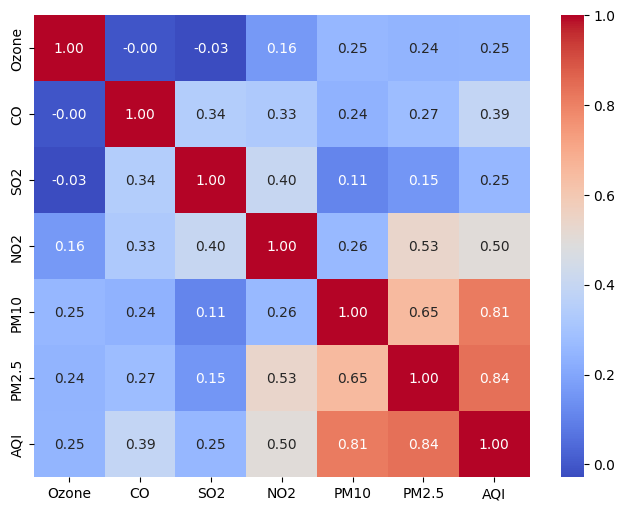

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df_cleaned.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f")

Text(0.5, 1.0, 'AIR QUALITY %')

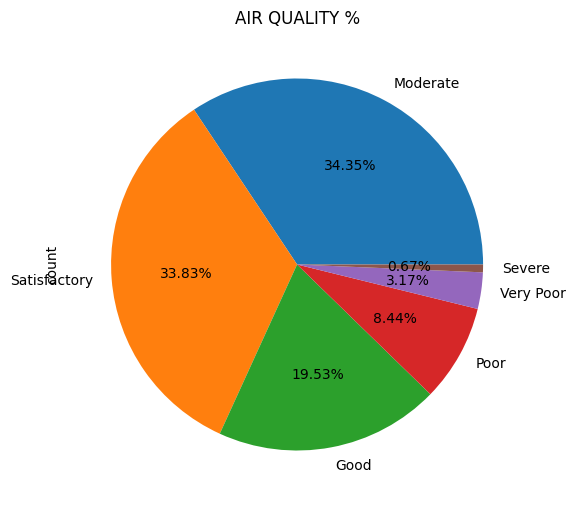

In [15]:
# Pie chart showing percentage of air quality in india at major city
plt.figure(figsize=(6, 8))
df_cleaned['AQI_Brief'].value_counts().plot(kind='pie',autopct='%1.2f%%',)
plt.title("AIR QUALITY %")

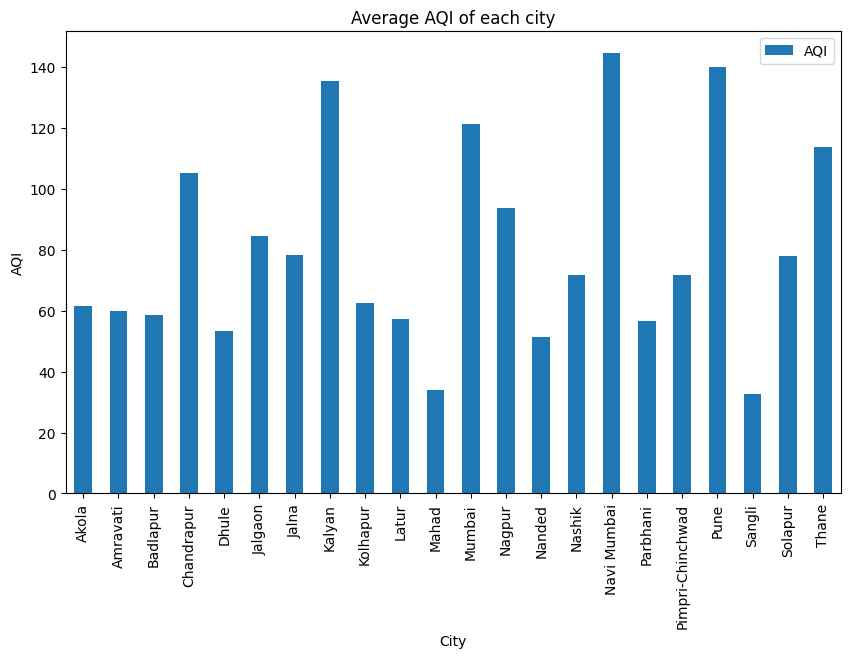

In [13]:
plt.figure(figsize=(10,6))
df_cleaned.groupby('City')['AQI'].mean().plot(kind='bar')
plt.legend()
plt.title("Average AQI of each city")
plt.ylabel("AQI")
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

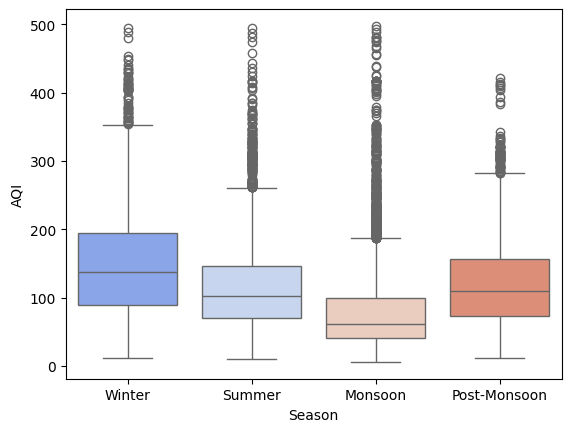

In [16]:
#Season Wise Trend Analysis Of AQI
df_ForMonth=pd.read_csv("Final_data.csv")
df_ForMonth['From Date']=pd.to_datetime(df_ForMonth['From Date'])
df_ForMonth['Month']=df_ForMonth['From Date'].dt.month.astype(int)
def get_season(month):
  if month in [12,1,2]:
    return "Winter"
  elif month in [3,4,5]:
    return "Summer"
  elif month in [6,7,8,9]:
    return "Monsoon"
  else:
    return "Post-Monsoon"

df_ForMonth['Season']=df_ForMonth['Month'].apply(get_season)

#Visualizations
sns.boxplot(x='Season', y='AQI', data=df_ForMonth, palette="coolwarm", hue="Season",legend=False)
plt

1.Mumbai
2.Chandrapur
3.Pune
4.Solapur
5.Nagpur
6.Nashik
7.Thane
8.Navi Mumbai
9.Kalyan
10.Pimpri-Chinchwad
11.Kolhapur
12.Sangli
13.Latur
14.Mahad
15.Akola
16.Amravati
17.Jalgaon
18.Jalna
19.Parbhani
20.Nanded
21.Badlapur
22.Dhule
-------------------------------------------------------------------
Enter city name:pune


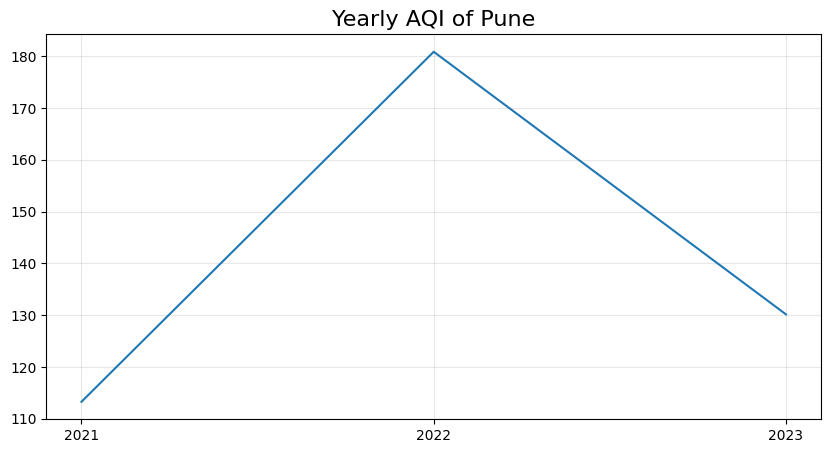

In [20]:

list_cities=df_cleaned['City'].unique()
c=1
for i in range(len(list_cities)):
  print(f'{c}.{list_cities[i]}')
  c+=1
def Yearly_graph(input_city):
  import calendar
  df_ForYear=pd.read_csv("Final_data.csv")
  df_ForYear['From Date']=pd.to_datetime(df_ForYear['From Date'])
  df_ForYear['Year']=df_ForYear['From Date'].dt.year.astype(int)
  df_city=df_ForYear[df_ForYear['City']==input_city]
  city_yearly_aqi=df_city.groupby('Year')['AQI'].mean().reset_index()

  plt.figure(figsize=(10,5))
  plt.plot(city_yearly_aqi['Year'],city_yearly_aqi['AQI'])
  plt.title(f"Yearly AQI of {input_city}",fontsize=16)
  plt.xticks(city_yearly_aqi['Year'])
  plt.grid(alpha=0.3)
  plt.show()
print('-------------------------------------------------------------------')
input_city=input("Enter city name:").capitalize()
Yearly_graph(input_city)

1.Mumbai
2.Chandrapur
3.Pune
4.Solapur
5.Nagpur
6.Nashik
7.Thane
8.Navi Mumbai
9.Kalyan
10.Pimpri-Chinchwad
11.Kolhapur
12.Sangli
13.Latur
14.Mahad
15.Akola
16.Amravati
17.Jalgaon
18.Jalna
19.Parbhani
20.Nanded
21.Badlapur
22.Dhule
-------------------------------------------------------------------
Enter city name:mumbai


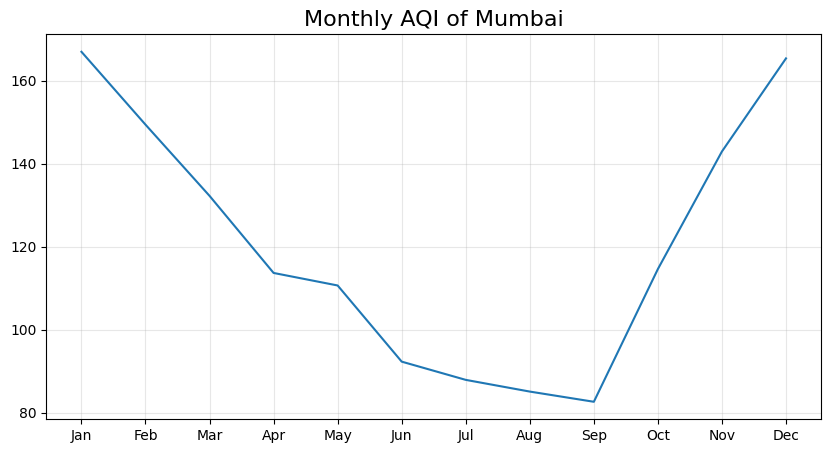

In [19]:
list_cities=df_cleaned['City'].unique()
c=1
for i in range(len(list_cities)):
  print(f'{c}.{list_cities[i]}')
  c+=1
def monthly_graph(input_city):
  import calendar
  df_ForMonth=pd.read_csv("Final_data.csv")
  df_ForMonth['From Date']=pd.to_datetime(df_ForMonth['From Date'])
  df_ForMonth['Month']=df_ForMonth['From Date'].dt.month.astype(int)
  df_city=df_ForMonth[df_ForMonth['City']==input_city]
  city_monthly_aqi=df_city.groupby('Month')['AQI'].mean().reset_index()
  city_monthly_aqi['Month Name']=city_monthly_aqi['Month'].apply(lambda x: calendar.month_abbr[x])

  plt.figure(figsize=(10,5))
  plt.plot(city_monthly_aqi['Month Name'],city_monthly_aqi['AQI'])
  plt.title(f"Monthly AQI of {input_city}",fontsize=16)
  plt.xticks(city_monthly_aqi['Month Name'])
  plt.grid(alpha=0.3)
  plt.show()
print('-------------------------------------------------------------------')
input_city=input("Enter city name:").capitalize()
monthly_graph(input_city)

Let's Predict whethar it is safe or Unhealthy by Date and City Only

In [21]:
#Importing all the Tools of sklearn library
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [22]:
df=pd.read_csv("Final_data.csv")
df["From Date"]=pd.to_datetime(df["From Date"])
df=df.sort_values(by=["City","From Date"])
df.head()

,From Date,To Date,Ozone,CO,SO2,NO2,PM10,PM2.5,State,City,AQI,AQI_Brief
13020,2023-01-07,2023-02-07,25.34,0.46,5.69,7.33,44.22,17.27,Maharashtra,Akola,44.22,Good
13021,2023-02-07,2023-03-07,23.98,0.46,10.04,9.33,35.36,15.75,Maharashtra,Akola,35.36,Good
13022,2023-03-07,2023-04-07,24.84,0.62,8.94,10.50,61.16,24.67,Maharashtra,Akola,61.16,Satisfactory
13023,2023-04-07,2023-05-07,21.57,0.58,7.89,6.96,73.56,30.05,Maharashtra,Akola,73.56,Satisfactory
13024,2023-05-07,2023-06-07,22.08,0.47,6.68,5.21,34.42,14.64,Maharashtra,Akola,34.42,Good


In [23]:
df["Next_day"]=df.groupby("City")["AQI_Brief"].shift(-1)
binary_selec={"Good":"Safe","Satisfactory":"Safe","Moderate":"Safe","Poor":"Unhealthy","Very Poor":"Unhealthy","Severe":"Unhealthy"}
df["Target"]=df["Next_day"].map(binary_selec)
df.head(10)

,From Date,To Date,Ozone,CO,SO2,NO2,PM10,PM2.5,State,City,AQI,AQI_Brief,Next_day,Target
13020,2023-01-07,2023-02-07,25.34,0.46,5.69,7.33,44.22,17.27,Maharashtra,Akola,44.22,Good,Good,Safe
13021,2023-02-07,2023-03-07,23.98,0.46,10.04,9.33,35.36,15.75,Maharashtra,Akola,35.36,Good,Satisfactory,Safe
13022,2023-03-07,2023-04-07,24.84,0.62,8.94,10.50,61.16,24.67,Maharashtra,Akola,61.16,Satisfactory,Satisfactory,Safe
13023,2023-04-07,2023-05-07,21.57,0.58,7.89,6.96,73.56,30.05,Maharashtra,Akola,73.56,Satisfactory,Good,Safe
13024,2023-05-07,2023-06-07,22.08,0.47,6.68,5.21,34.42,14.64,Maharashtra,Akola,34.42,Good,Good,Safe
13025,2023-06-07,2023-07-07,22.98,0.36,1.84,4.56,30.40,12.32,Maharashtra,Akola,30.40,Good,Satisfactory,Safe
13005,2023-06-13,2023-06-14,52.07,0.58,12.77,6.10,83.75,39.53,Maharashtra,Akola,83.75,Satisfactory,Satisfactory,Safe
13006,2023-06-14,2023-06-15,51.19,0.61,12.05,4.72,89.21,40.00,Maharashtra,Akola,89.21,Satisfactory,Satisfactory,Safe
13007,2023-06-15,2023-06-16,46.85,0.70,11.72,8.52,94.17,41.50,Maharashtra,Akola,94.17,Satisfactory,Moderate,Safe
13008,2023-06-16,2023-06-17,51.83,0.64,11.22,5.94,108.64,50.51,Maharashtra,Akola,106.08,Moderate,Moderate,Safe


In [24]:
#Feature Engineering3

df["Month"]=df["From Date"].dt.month
df["Day of week"]=df["From Date"].dt.dayofweek
df["Current AQI"]=df["AQI"]
#drop nan
df_model=df.dropna(subset=["Target"])

In [25]:
#select features
features_num=["Month","Day of week","Current AQI","PM10","PM2.5","NO2","SO2","CO","Ozone"]
features_cat=["City"]
x=df_model[features_num+features_cat]
y=df_model["Target"]

In [26]:
#Building Pipeline for processing and using model
preprocessor = ColumnTransformer(
    transformers=[("num",StandardScaler(),features_num),
                  ("cat",OrdinalEncoder(),features_cat)
                  ])
model=Pipeline(steps=[("preprocessor",preprocessor),("Classifier",RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42))])


In [27]:
#train and testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [28]:
#evalution
acc=accuracy_score(y_test,y_pred)
print(f"Prediction Accuracy: {acc*100:.2f}%")
print(classification_report(y_test,y_pred))

Prediction Accuracy: 90.84%
              precision    recall  f1-score   support

        Safe       0.92      0.98      0.95      2411
   Unhealthy       0.69      0.39      0.50       319

    accuracy                           0.91      2730
   macro avg       0.81      0.68      0.72      2730
weighted avg       0.90      0.91      0.90      2730

